
## **1. Imports**


In [78]:
!pip install pandas requests tqdm

In [79]:
import os
from pathlib import Path

def _load_key_from_env_file(env_path: Path, key_name: str = "OPENROUTER_API_KEY") -> str:
    if not env_path.exists():
        return ""
    for line in env_path.read_text(encoding="utf-8").splitlines():
        s = line.strip()
        if not s or s.startswith("#") or "=" not in s:
            continue
        k, v = s.split("=", 1)
        if k.strip() == key_name:
            return v.strip().strip('"').strip("'")
    return ""

ENV_PATH = Path("eval/.env")
if not ENV_PATH.exists():
    ENV_PATH = Path("eval.env")
if not ENV_PATH.exists():
    ENV_PATH = Path("../../.env")

OPENROUTER_API_KEY = _load_key_from_env_file(ENV_PATH) or os.environ.get("OPENROUTER_API_KEY", "")
assert OPENROUTER_API_KEY, f"OPENROUTER_API_KEY was not found in {ENV_PATH} or environment variables"
print(f"OPENROUTER_API_KEY loaded ({'env file' if _load_key_from_env_file(ENV_PATH) else 'environment'})")

OPENROUTER_API_KEY is set


In [82]:
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

MODEL = "google/gemini-3.1-pro-preview"   # or "anthropic/claude-opus-4.6"

# I/O
INPUT_CSV = "dataset/2_rules_understanding.csv"
OUTPUT_CSV = "2_3_with_answers_gemini-3_1-pro-preview.csv"
OUTPUT_JSONL = "2_3_gemini-3_1-pro-preview_raw.jsonl"

# Column in CSV that contains the prompt/question
QUESTION_COL = "question_text"
IMAGE_COL = "figure_path"
INSTRUCTION_SUFFIX = "Follow the answer format exactly! Answer with ONE token. NO explanation. JUST AN ANSWER"
EXPLANATION_SUFFIX = "Provide a BRIEF explanation of your choice. LIMIT your answer to 200-250 words ONLY."

# Generation params
MAX_TOKENS = 100
TEMPERATURE = 0.0
REASONING = {"effort": "minimal", "exclude": True}
MAX_FORMAT_RETRIES = 2
EXPLANATION_MAX_TOKENS = 512

## **2. Preview dataset CSV**

In [84]:
dataset = pd.read_csv("dataset/2_rules_understanding.csv")
dataset = dataset[dataset["layer_id"].astype(str).str.strip() == "2_3"].copy()
dataset.head()

def normalize_path(p):
    if not isinstance(p, str):
        return None
    p = p.strip()
    p = p.strip('"')
    return p


dataset["figure_path"] = dataset["figure_path"].apply(normalize_path)

def is_valid_image(p):
    try:
        if not os.path.exists(p):
            return False
        Image.open(p).verify()
        return True
    except Exception:
        return False

dataset["image_ok"] = dataset["figure_path"].apply(is_valid_image)

dataset["image_ok"].value_counts()


image_ok
False    134
Name: count, dtype: int64

In [85]:
sample = dataset.iloc[10]

print(sample["figure_path"])
print(os.path.exists(str(sample["figure_path"])))
print(dataset["figure_path"].head(5))

print("raw:", repr(sample["figure_path"]))
print("exists:", os.path.exists(str(sample["figure_path"])))

C:\Users\ritaMZ\WebstormProjects\thesis\backend\rule_figure\Figure88.jpg
True
0                                                 None
1    C:\Users\ritaMZ\WebstormProjects\thesis\backen...
2    C:\Users\ritaMZ\WebstormProjects\thesis\backen...
3    C:\Users\ritaMZ\WebstormProjects\thesis\backen...
4                                                 None
Name: figure_path, dtype: object
raw: 'C:\\Users\\ritaMZ\\WebstormProjects\\thesis\\backend\\rule_figure\\Figure88.jpg'
exists: True


Is the following regulation ambiguous?

Rule:
The following activities take place in a semi-ambulant WC (see Figure 88): use of the toilet; disposal of sanitary towels (optional); hand-rinsing. 

Emerald (Greenish) Zone: Semi-ambulant Toilet Activity Space represents the required clearance for approaching and using the semi-ambulant toilet. 
Low-Level Space: A clear space of 600 mm (height, width and depth) is required in front of the toilet pan at a low level to allow for user positioning. Overall Width: The entire activity zone for the toilet should have a width of 800 mm and 600 depth on the upper level. 

Purple (Pinkish) zone corresponds to the activity space for using the ambulant/semi-ambulant hand-rinse basin, with distinct requirements at different heights:
Low-Level Space: At a low level, a clear space with a width of 800 mm(depth and height 600) is required for a user to approach and stand at the basin.
Higher-Level Space: For the upper body, a wider space of 1000 mm (depth 

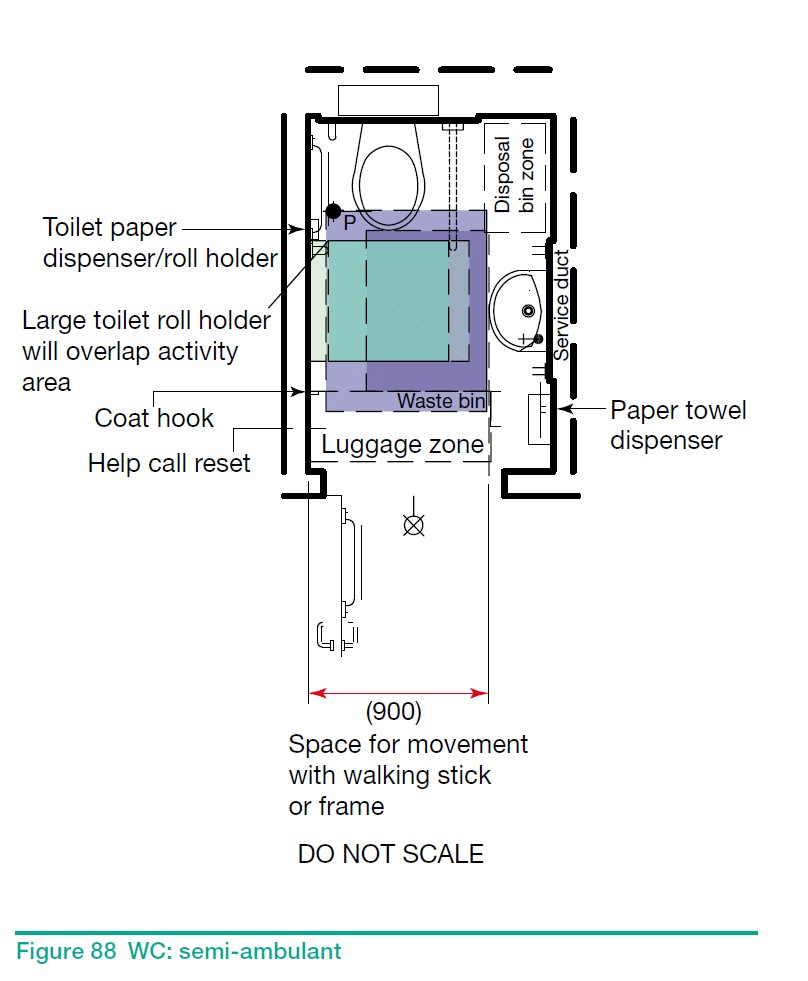

In [86]:
import os
from PIL import Image as PILImage
from IPython.display import display

dataset = dataset.drop(columns=["image_ok"], errors="ignore")

sample = dataset.iloc[10]
p = sample["figure_path"]

print(sample["question_text"])
if isinstance(p, str) and os.path.exists(p):
    display(PILImage.open(p))
else:
    print("No local image available for this question.")


## 3. OpenRouter call utilities

In [87]:
import base64
import json
import re
import mimetypes
import time
from typing import Any, Dict, Optional

import requests


def build_headers(api_key: str) -> Dict[str, str]:
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }
    return headers


def check_key_info(api_key: str) -> Dict[str, Any]:
    """GET /key ? check usage/credits for the key."""
    r = requests.get(f"{OPENROUTER_BASE_URL}/key", headers=build_headers(api_key), timeout=30)
    r.raise_for_status()
    return r.json()

def build_prompt(question_text: str, instruction_suffix: Optional[str] = None) -> str:
    q = "" if question_text is None else str(question_text).strip()
    suffix = INSTRUCTION_SUFFIX if instruction_suffix is None else instruction_suffix
    if suffix:
        return f"{q}\n\n{suffix}"
    return q

def to_image_url(image_value: str) -> str:
    s = "" if image_value is None else str(image_value).strip().strip('"').strip("'")
    if not s:
        raise ValueError("Empty image value")
    p = Path(s)
    if not p.exists():
        raise FileNotFoundError(s)
    mime, _ = mimetypes.guess_type(p.name)
    if not mime:
        mime = "image/jpeg"
    data = p.read_bytes()
    b64 = base64.b64encode(data).decode("ascii")
    return f"data:{mime};base64,{b64}"

def call_openrouter_chat(api_key: str, prompt: str, image_value: str, request_id: str | None = None, max_tokens: Optional[int] = None, temperature: Optional[float] = None, reasoning: Optional[Dict[str, Any]] = None, instruction_suffix: Optional[str] = None) -> dict:
    url = f"{OPENROUTER_BASE_URL}/chat/completions"

    def _has_image(v) -> bool:
        if v is None:
            return False
        try:
            import pandas as _pd
            if _pd.isna(v):
                return False
        except Exception:
            pass
        s = str(v).strip().strip('"').strip("'")
        if not s:
            return False
        return Path(s).exists()

    prompt_final = build_prompt(prompt, instruction_suffix=instruction_suffix)
    content = [{"type": "text", "text": prompt_final}]
    if _has_image(image_value):
        image_url = to_image_url(image_value)
        content.append({"type": "image_url", "image_url": {"url": image_url}})

    payload = {
        "model": MODEL,
        "messages": [
            {
                "role": "user",
                "content": content,
            }
        ],
        "max_tokens": MAX_TOKENS if max_tokens is None else max_tokens,
        "temperature": TEMPERATURE if temperature is None else temperature,
        "reasoning": REASONING if reasoning is None else reasoning,
    }

    if request_id is not None:
        payload["metadata"] = {"request_id": request_id}

    r = requests.post(url, headers=build_headers(api_key), data=json.dumps(payload), timeout=120)
    if r.status_code >= 400:
        try:
            err = r.json()
        except Exception:
            err = {"error": {"message": r.text}}
        raise RuntimeError(f"OpenRouter error {r.status_code}: {err}")

    return r.json()



def call_with_retries(api_key: str, prompt: str, image_value: str, request_id: str, max_retries: int = 6, max_tokens: Optional[int] = None, temperature: Optional[float] = None, reasoning: Optional[Dict[str, Any]] = None, instruction_suffix: Optional[str] = None) -> Dict[str, Any]:
    """Retries for transient errors (429/502/503/408)."""
    backoff = 2.0
    for attempt in range(max_retries + 1):
        try:
            return call_openrouter_chat(
                api_key,
                prompt,
                image_value,
                request_id=request_id,
                max_tokens=max_tokens,
                temperature=temperature,
                reasoning=reasoning,
                instruction_suffix=instruction_suffix,
            )
        except RuntimeError as e:
            msg = str(e)
            retriable = any(code in msg for code in [" 429:", " 502:", " 503:", " 408:"])
            if (attempt == max_retries) or (not retriable):
                raise
            time.sleep(backoff)
            backoff *= 1.7
    raise RuntimeError("Unreachable")


def extract_text(resp: Dict[str, Any]) -> str:
    """choices[0].message.content"""
    try:
        return resp["choices"][0]["message"]["content"]
    except Exception:
        return ""


def normalize_answer(text: Any) -> str:
    if text is None:
        return ""
    t = str(text).strip()

    # Strip code fences if present
    if "```" in t:
        parts = t.split("```")
        if len(parts) >= 3:
            t = parts[1]
        else:
            t = parts[-1]

    t = t.strip()

    # Try JSON payloads like {"answer": "no"}
    if t.startswith("{") or t.startswith("["):
        try:
            obj = json.loads(t)
            if isinstance(obj, dict):
                for key in ["answer", "final", "response", "result"]:
                    if key in obj:
                        t = str(obj[key])
                        break
            elif isinstance(obj, str):
                t = obj
        except Exception:
            pass

    t = t.strip().strip("\"").strip("'")
    t = re.sub(r"^[`\"']+|[`\"']+$", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    t = t.strip(".")
    return t.lower()


def normalize_expected(text: Any) -> str:
    if text is None:
        return ""
    t = str(text).strip().strip("\"").strip("'")
    t = re.sub(r"\s+", " ", t).strip()
    t = t.strip(".")
    return t.lower()


def is_valid_answer(text: str) -> bool:
    return bool(re.fullmatch(r"(yes|no|\d+)", text))


def get_valid_answer(api_key: str, prompt: str, image_value: str, request_id: str, max_format_retries: int = 2) -> tuple[str, list[Dict[str, Any]]]:
    attempts: list[Dict[str, Any]] = []
    for attempt in range(max_format_retries + 1):
        resp = call_with_retries(api_key, prompt, image_value, request_id=request_id)
        raw = extract_text(resp)
        norm = normalize_answer(raw)
        valid = is_valid_answer(norm)
        attempts.append({
            "attempt": attempt,
            "raw": raw,
            "normalized": norm,
            "valid": valid,
            "response": resp,
        })
        if valid:
            break
    if not attempts:
        return "", []
    return attempts[-1]["normalized"], attempts


def get_explanation(api_key: str, prompt: str, image_value: str, request_id: str) -> tuple[str, Dict[str, Any]]:
    resp = call_with_retries(
        api_key,
        prompt,
        image_value,
        request_id=request_id,
        max_tokens=EXPLANATION_MAX_TOKENS,
        instruction_suffix=EXPLANATION_SUFFIX,
    )
    return extract_text(resp), resp

In [88]:
from pathlib import Path

def clean_path(s):
    s = str(s).strip().strip('"').strip("'")
    return s

missing = []
for i, s in enumerate(df[IMAGE_COL].head(50)):
    p = Path(clean_path(s))
    if not p.exists():
        missing.append((i, s))

missing[:5], len(missing)


([(0, None), (4, None), (5, None), (6, None), (8, None)], 24)

In [ ]:
info = check_key_info(OPENROUTER_API_KEY)
info

## 4. Run CSV -> model answers -> save
We save:
- `OUTPUT_CSV` ? input columns + `model`, `openrouter_request_id`, `model_answer`
- `OUTPUT_JSONL` ? raw responses (useful for debugging/auditing)

=== PREVIEW: prompt_final ===
Is the following regulation ambiguous?

Rule:
The following activities take place in a semi-ambulant WC (see Figure 88): use of the toilet; disposal of sanitary towels (optional); hand-rinsing. 

Emerald (Greenish) Zone: Semi-ambulant Toilet Activity Space represents the required clearance for approaching and using the semi-ambulant toilet. 
Low-Level Space: A clear space of 600 mm (height, width and depth) is required in front of the toilet pan at a low level to allow for user positioning. Overall Width: The entire activity zone for the toilet should have a width of 800 mm and 600 depth on the upper level. 

Purple (Pinkish) zone corresponds to the activity space for using the ambulant/semi-ambulant hand-rinse basin, with distinct requirements at different heights:
Low-Level Space: At a low level, a clear space with a width of 800 mm(depth and height 600) is required for a user to approach and stand at the basin.
Higher-Level Space: For the upper body, a 

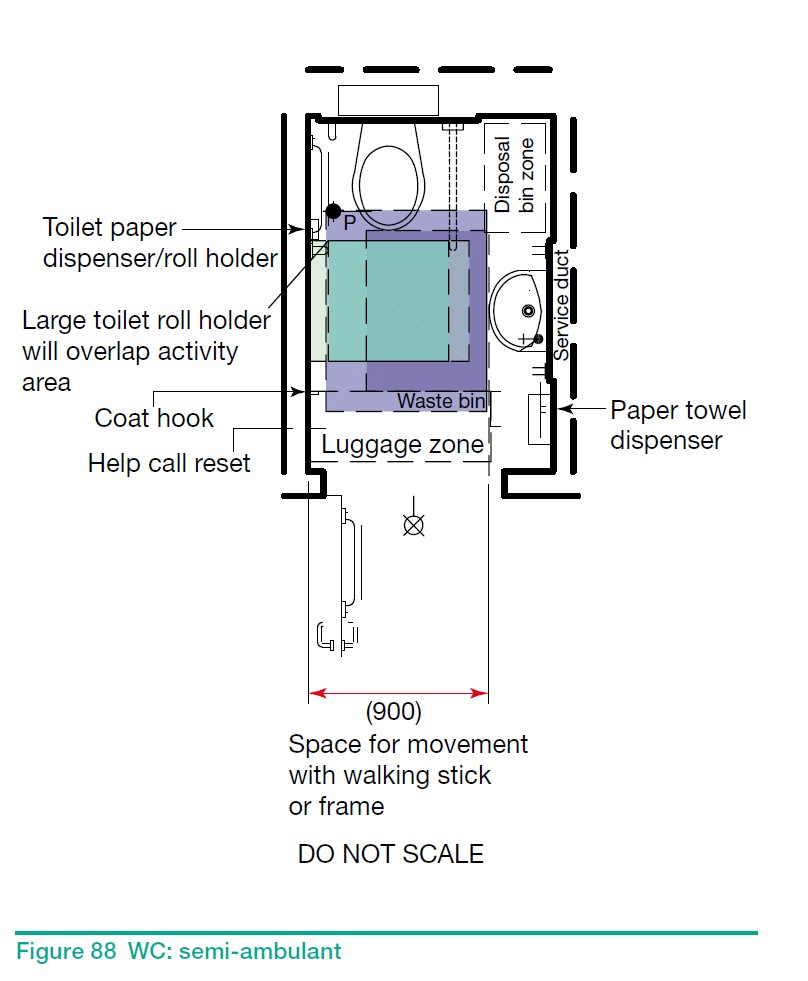

In [89]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Markdown, Image

INPUT_CSV="dataset/2_rules_understanding.csv"
df = pd.read_csv(INPUT_CSV)
df = df[df["layer_id"].astype(str).str.strip() == "2_3"].copy()

PREVIEW_ROW = 10

row = df.iloc[PREVIEW_ROW]

question = str(row[QUESTION_COL])
image_path = str(row[IMAGE_COL])

prompt_final = build_prompt(question)

print("=== PREVIEW: prompt_final ===")
print(prompt_final)
print("\n=== PREVIEW: image_path ===")
print(image_path)

p = Path(image_path.strip().strip('"').strip("'"))
if p.exists():
    display(Image(filename=str(p)))
else:
    print("⚠️ Image file not found locally. If it's a URL, that's fine.")


In [90]:
COL_TEMPLATE = "template_id"

In [91]:
df[IMAGE_COL].isna().sum(), len(df)
df[df[IMAGE_COL].isna()][[COL_TEMPLATE, QUESTION_COL, IMAGE_COL]].head(10)


,template_id,question_text,figure_path
0,32.0,Is the following regulation ambiguous? A regul...,NaN
4,32.0,Is the following regulation ambiguous? A regul...,NaN
5,32.0,Is the following regulation ambiguous? A regul...,NaN
6,32.0,Is the following regulation ambiguous? A regul...,NaN
8,32.0,Is the following regulation ambiguous? A regul...,NaN
9,33.0,Is the following regulation ambiguous?\n\nRule...,NaN
13,33.0,Is the following regulation ambiguous?\n\nRule...,NaN
14,33.0,Is the following regulation ambiguous?\n\nRule...,NaN
15,33.0,Is the following regulation ambiguous?\n\nRule...,NaN
17,33.0,Is the following regulation ambiguous?\n\nRule...,NaN


In [92]:
missing_img = df[df[IMAGE_COL].isna()]
print("Rows with NaN in file_path:", missing_img.index.tolist()[:50], "…")
print("Count:", len(missing_img))

missing_img[[QUESTION_COL, IMAGE_COL]].head(10)


Rows with NaN in file_path: [0, 4, 5, 6, 8, 9, 13, 14, 15, 17, 18, 25, 26, 34, 35, 36, 37, 38, 41, 42, 44, 45, 46, 47, 54, 55, 63, 64, 65, 66, 67, 70, 71, 73, 74, 75, 76, 83, 84, 92, 93, 94, 95, 96, 99, 100, 102, 103, 104, 105] …
Count: 62


,question_text,figure_path
0,Is the following regulation ambiguous? A regul...,NaN
4,Is the following regulation ambiguous? A regul...,NaN
5,Is the following regulation ambiguous? A regul...,NaN
6,Is the following regulation ambiguous? A regul...,NaN
8,Is the following regulation ambiguous? A regul...,NaN
9,Is the following regulation ambiguous?\n\nRule...,NaN
13,Is the following regulation ambiguous?\n\nRule...,NaN
14,Is the following regulation ambiguous?\n\nRule...,NaN
15,Is the following regulation ambiguous?\n\nRule...,NaN
17,Is the following regulation ambiguous?\n\nRule...,NaN


### Preview: 15 random questions

In [93]:
import pandas as pd
from tqdm import tqdm

PREVIEW_N = 12
PREVIEW_SEED = 60
INPUT_CSV = "dataset/2_rules_understanding.csv"

df_preview = pd.read_csv(INPUT_CSV)
df_preview = df_preview[df_preview["layer_id"].astype(str).str.strip() == "2_3"].copy()
assert QUESTION_COL in df_preview.columns, f"CSV must contain column '{QUESTION_COL}'. Found: {list(df_preview.columns)}"
assert IMAGE_COL in df_preview.columns, f"CSV must contain column '{IMAGE_COL}'. Found: {list(df_preview.columns)}"

sample_df = df_preview.sample(n=min(PREVIEW_N, len(df_preview)), random_state=PREVIEW_SEED)

preview_rows = []
for i, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    prompt = str(row[QUESTION_COL])
    image_value = row[IMAGE_COL]
    if pd.isna(image_value):
        image_value = None
    request_id = f"preview_row_{i}"

    text, attempts = get_valid_answer(
        OPENROUTER_API_KEY, prompt, image_value, request_id, MAX_FORMAT_RETRIES
    )
    raw_first = attempts[0]["raw"] if attempts else ""
    raw_final = attempts[-1]["raw"] if attempts else ""
    fmt_attempts = max(len(attempts) - 1, 0)
    expected = normalize_expected(row.get("correct_answer"))
    is_correct = bool(expected) and (text == expected)
    explanation_text = ""
    if is_correct:
        explanation_text, _ = get_explanation(
            OPENROUTER_API_KEY, prompt, image_value, f"{request_id}_explain"
        )

    preview_rows.append({
        "row_index": i,
        "question_text": prompt,
        "figure_path": image_value,
        "correct_answer": row.get("correct_answer"),
        "model_answer": text,
        "model_answer_raw_first": raw_first,
        "model_answer_raw_final": raw_final,
        "is_correct": is_correct,
        "explanation": explanation_text,
        "openrouter_request_id": request_id,
        "format_retries": fmt_attempts,
    })

preview_df = pd.DataFrame(preview_rows).sort_values("row_index")
preview_df


100%|██████████| 12/12 [02:24<00:00, 12.05s/it]


,row_index,question_text,figure_path,correct_answer,model_answer,model_answer_raw_first,model_answer_raw_final,is_correct,explanation,openrouter_request_id,format_retries
4,3,Is the following regulation ambiguous? A regul...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",no,yes,yes,yes,False,,preview_row_3,0
2,14,Is the following regulation ambiguous?\n\nRule...,None,yes,yes,Yes,Yes,True,Yes.\n\nThe regulation is highly ambiguous due...,preview_row_14,0
6,19,This regulation is ambiguous. Which main categ...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",1,3,3,3,False,,preview_row_19,0
7,22,This regulation is ambiguous. Which main categ...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",3,3,3,3,True,3\n\nThe ambiguity in this regulation falls un...,preview_row_22,0
11,30,This regulation is ambiguous. Which main categ...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",3,1,1,1,False,,preview_row_30,0
3,33,This regulation is ambiguous. Which main categ...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",3,3,3,3,True,1\n\nThe ambiguity in this regulation falls un...,preview_row_33,0
5,35,This regulation is ambiguous. Which main categ...,None,2,1,1,1,False,,preview_row_35,0
0,76,Consider the following rule. If this rule cont...,None,2,1,1,1,False,,preview_row_76,0
9,116,Consider the following rule. If this rule cont...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",2,2,2,2,True,"2\n\nThe rule ""The position of the shower seat...",preview_row_116,0
10,128,Consider the following rule. If this rule cont...,None,2,2,2,2,True,"2\n\nThe rule falls under sub-category 2, ""No ...",preview_row_128,0


### Run the dataset on the model:

In [94]:
import pandas as pd
from tqdm import tqdm
import json

INPUT_CSV="dataset/2_rules_understanding.csv"

df = pd.read_csv(INPUT_CSV)
df = df[df["layer_id"].astype(str).str.strip() == "2_3"].copy()
assert QUESTION_COL in df.columns, f"CSV must contain column '{QUESTION_COL}'. Found: {list(df.columns)}"
assert IMAGE_COL in df.columns, f"CSV must contain column '{IMAGE_COL}'. Found: {list(df.columns)}"

answers = []
raw_first_list = []
raw_final_list = []
format_retries_list = []
is_correct_list = []
explanation_list = []
req_ids = []

with open(OUTPUT_JSONL, "w", encoding="utf-8") as fjsonl:
    for i, row in tqdm(df.iterrows(), total=len(df)):
        prompt = str(row[QUESTION_COL])
        image_value = row[IMAGE_COL]
        if pd.isna(image_value):
            image_value = None
        request_id = f"row_{i}"

        text, attempts = get_valid_answer(
            OPENROUTER_API_KEY, prompt, image_value, request_id, MAX_FORMAT_RETRIES
        )
        raw_first = attempts[0]["raw"] if attempts else ""
        raw_final = attempts[-1]["raw"] if attempts else ""
        fmt_attempts = max(len(attempts) - 1, 0)
        final_resp = attempts[-1]["response"] if attempts else {}
        expected = normalize_expected(row.get("correct_answer"))
        is_correct = bool(expected) and (text == expected)
        explanation_text = ""
        explanation_resp = {}
        if is_correct:
            explanation_text, explanation_resp = get_explanation(
                OPENROUTER_API_KEY, prompt, image_value, f"{request_id}_explain"
            )

        fjsonl.write(json.dumps(
            {
                "row_index": i,
                "request_id": request_id,
                "prompt": prompt,
                "image_value": image_value,
                "response": final_resp,
                "attempts": attempts,
                "is_correct": is_correct,
                "explanation": {
                    "text": explanation_text,
                    "response": explanation_resp,
                },
            },
            ensure_ascii=False
        ) + "\n")

        answers.append(text)
        raw_first_list.append(raw_first)
        raw_final_list.append(raw_final)
        format_retries_list.append(fmt_attempts)
        is_correct_list.append(is_correct)
        explanation_list.append(explanation_text)
        req_ids.append(request_id)

df["model"] = MODEL
df["openrouter_request_id"] = req_ids
df["model_answer"] = answers
df["model_answer_raw_first"] = raw_first_list
df["model_answer_raw_final"] = raw_final_list
df["format_retries"] = format_retries_list
df["is_correct"] = is_correct_list
df["explanation"] = explanation_list

df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Saved:", OUTPUT_JSONL)

df.head(3)

100%|██████████| 134/134 [23:27<00:00, 10.50s/it]

Saved: 2_3_with_answers_gemini-3_1-pro-preview.csv
Saved: 2_3_gemini-3_1-pro-preview_raw.jsonl


,generated_question_id,template_id,question_text,figure_path,correct_answer,model,openrouter_request_id,model_answer,model_answer_raw_first,model_answer_raw_final,format_retries,is_correct,explanation
0,8,32.0,Is the following regulation ambiguous? A regul...,NaN,yes,google/gemini-3.1-pro-preview,row_0,yes,Yes,Yes,0,True,**No**\n\n**Explanation:**\n\nThe regulation i...
1,9,32.0,Is the following regulation ambiguous? A regul...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",yes,google/gemini-3.1-pro-preview,row_1,no,No,No,0,False,
2,10,32.0,Is the following regulation ambiguous? A regul...,"""C:\Users\ritaMZ\WebstormProjects\thesis\backe...",yes,google/gemini-3.1-pro-preview,row_2,yes,yes,yes,0,True,Yes.\n\nThe regulation is ambiguous because it...


### Sanity check:

In [95]:
import numpy as np

lens = df["model_answer"].fillna("").astype(str).map(len)
print("Rows:", len(df))
print("Empty answers:", int((lens == 0).sum()))
print("Median length:", int(np.median(lens)))
print("P90 length:", int(np.quantile(lens, 0.9)))

Rows: 134
Empty answers: 0
Median length: 1
P90 length: 3


# 5. Metrics

In [59]:
import json
import pandas as pd

JSONL_PATH = "2_3_gemini-3_1-pro-preview_raw.jsonl"
QUESTIONS_CSV = "dataset/2_rules_understanding.csv"
OUT_CSV = "2_3_clean_gemini-3_1-pro-preview.csv"
TARGET_LAYER = "2_3"

# 1) ответы из jsonl (последний ответ для каждого row_index)
ans_map = {}
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line)
        row_index = rec.get("row_index")
        request_id = rec.get("request_id")
        resp = rec.get("response", {}) or {}

        try:
            text = resp["choices"][0]["message"]["content"]
        except Exception:
            text = ""

        ans_map[row_index] = {
            "openrouter_request_id": request_id,
            "model_answer": text,
        }

# 2) questions + GT
df_q = pd.read_csv(QUESTIONS_CSV)
df_q["row_index"] = df_q.index
df_q["openrouter_request_id"] = df_q["row_index"].map(lambda i: ans_map.get(i, {}).get("openrouter_request_id"))
df_q["model_answer"] = df_q["row_index"].map(lambda i: ans_map.get(i, {}).get("model_answer", ""))
df_q["target_layer"] = TARGET_LAYER

df_final = df_q[[
    "row_index",
    "template_id",
    "correct_answer",
    "model_answer",
    "openrouter_request_id",
]].copy()
assert len(df_final) == len(df_q), "Row count changed; check mapping"

df_final.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
df_final.head()


Saved: 2_3_with_answers_gemini-3_1-pro-preview.csv


,row_index,template_id,correct_answer,model_answer,openrouter_request_id
0,0,32.0,yes,,row_0
1,1,32.0,yes,no,row_1
2,2,32.0,yes,yes,row_2
3,3,32.0,no,yes,row_3
4,4,32.0,no,No.,row_4


In [96]:
import pandas as pd
import re

#INPUT = "output_with_answers_recovered.csv"
INPUT = "2_3_with_answers_gemini-3_1-pro-preview.csv"
#INPUT = "1_1_1_Eval_Claude_Opus_1.csv"

COL_TEMPLATE = "template_id"
COL_GT = "correct_answer"
COL_PRED = "model_answer"

df = pd.read_csv(INPUT)

def normalize_text(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_label(s: str) -> str:
    t = normalize_text(s)
    if t in {"yes", "true"}:
        return "yes"
    if t in {"no", "false"}:
        return "no"
    return t

def contains_whole_word(text: str, word: str) -> bool:
    if not word:
        return False
    pattern = r"(?:^|\s)" + re.escape(word) + r"(?:$|\s)"
    return re.search(pattern, text) is not None

df["gt_norm"] = df[COL_GT].apply(normalize_label)
df["pred_norm_text"] = df[COL_PRED].apply(normalize_text)

def predicted_label_from_text(pred_text: str, gt_label: str) -> str:
    return gt_label if contains_whole_word(pred_text, gt_label) else ""

df["pred_label"] = [
    predicted_label_from_text(p, g)
    for p, g in zip(df["pred_norm_text"], df["gt_norm"])
]

# correctness
df["is_correct"] = df["pred_label"] == df["gt_norm"]

# ---- metrics per each template_id ----
def group_metrics(g: pd.DataFrame) -> pd.Series:
    n = len(g)
    acc = g["is_correct"].mean() if n else 0.0

    labels = sorted(set(g["gt_norm"].unique()) | set(g["pred_label"].unique()))
    labels = [lab for lab in labels if lab != ""]  # уберём пустой

    # F1:
    # - If only yes/no in GT -> binary F1 (positive=yes)
    # - Otherwise, macro F1 by GT classes (ignoring empty class)
    gt_set = set(g["gt_norm"].unique())
    if gt_set.issubset({"yes", "no"}):
        y_true = g["gt_norm"].tolist()
        y_pred = [("yes" if x == "yes" else "no") if x in {"yes","no"} else "no" for x in g["pred_label"].tolist()]
        # F1 positive=yes
        tp = sum((t == "yes") and (p == "yes") for t, p in zip(y_true, y_pred))
        fp = sum((t != "yes") and (p == "yes") for t, p in zip(y_true, y_pred))
        fn = sum((t == "yes") and (p != "yes") for t, p in zip(y_true, y_pred))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        f1_type = "binary(yes)"
    else:
        # macro F1 per GT classes
        y_true = g["gt_norm"].tolist()
        y_pred = g["pred_label"].tolist()

        f1s = []
        for lab in sorted(gt_set):
            tp = sum((t == lab) and (p == lab) for t, p in zip(y_true, y_pred))
            fp = sum((t != lab) and (p == lab) for t, p in zip(y_true, y_pred))
            fn = sum((t == lab) and (p != lab) for t, p in zip(y_true, y_pred))
            precision = tp / (tp + fp) if (tp + fp) else 0.0
            recall = tp / (tp + fn) if (tp + fn) else 0.0
            f1_lab = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
            f1s.append(f1_lab)
        f1 = sum(f1s) / len(f1s) if f1s else 0.0
        f1_type = "macro(GT-classes)"

    return pd.Series({
        "n": n,
        "accuracy": acc,
        "f1": f1,
        "f1_type": f1_type,
    })

rows = []
for template_id, g in df.groupby(COL_TEMPLATE, dropna=False):
    m = group_metrics(g)          # Series: n, accuracy, f1, f1_type
    m[COL_TEMPLATE] = template_id
    rows.append(m)

report = pd.DataFrame(rows).sort_values(COL_TEMPLATE).reset_index(drop=True)
report


,n,accuracy,f1,f1_type,template_id
0,9,0.555556,0.909091,binary(yes),32.0
1,9,0.555556,0.800000,binary(yes),33.0
2,29,0.413793,0.439560,macro(GT-classes),34.0
3,29,0.310345,0.609375,macro(GT-classes),35.0
4,29,0.137931,0.303571,macro(GT-classes),36.0
5,29,0.758621,0.234043,macro(GT-classes),37.0


In [97]:
# Summary metrics for selected template_id ranges
import numpy as np

def summarize_metrics(df_in: pd.DataFrame, template_ids, label: str):
    sub = df_in[df_in[COL_TEMPLATE].isin(template_ids)].copy()
    n = len(sub)
    acc = sub["is_correct"].mean() if n else 0.0
    f1 = group_metrics(sub)["f1"] if n else 0.0
    print(f"{label}: n={n}, accuracy={acc:.4f}, f1={f1:.4f}")

# accuracy for templates 34-37 (and report f1 too for completeness)
summarize_metrics(df, [34, 35, 36, 37], "templates 34-37")

# f1 for templates 32-33
summarize_metrics(df, [32, 33], "templates 32-33")

# f1 for templates 32-37
summarize_metrics(df, [32, 33, 34, 35, 36, 37], "templates 32-37")


templates 34-37: n=116, accuracy=0.4052, f1=0.5781
templates 32-33: n=18, accuracy=0.5556, f1=0.8571
templates 32-37: n=134, accuracy=0.4254, f1=0.5759


### Final Evaluation Summary Table

In [1]:
import pandas as pd
import re
from pathlib import Path

# ===== INPUT FILE =====
INPUT = "2_3_with_answers_gemini-3_1-pro-preview_V3.csv"

COL_TEMPLATE = "template_id"
COL_GT = "correct_answer"
COL_PRED = "model_answer"

# Resolve input path robustly
candidate_paths = [
    Path(INPUT),
    Path("results") / INPUT,
    Path("../results") / INPUT,
]

INPUT_PATH = next((pp for pp in candidate_paths if pp.exists()), None)
if INPUT_PATH is None:
    tried = [str(pp) for pp in candidate_paths]
    raise FileNotFoundError(f"Input file not found. Tried: {tried}")

print(f"Loading: {INPUT_PATH}")
df = pd.read_csv(INPUT_PATH)

# Optional: normalize template_id to numeric
df[COL_TEMPLATE] = pd.to_numeric(df[COL_TEMPLATE], errors="coerce")

def normalize_text(s: str) -> str:
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"[^\w\s]", " ", s, flags=re.UNICODE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_label(s: str) -> str:
    t = normalize_text(s)
    if t in {"yes", "true"}:
        return "yes"
    if t in {"no", "false"}:
        return "no"
    return t

def contains_whole_word(text: str, word: str) -> bool:
    if not word:
        return False
    pattern = r"(?:^|\s)" + re.escape(word) + r"(?:$|\s)"
    return re.search(pattern, text) is not None

# Ground truth normalization
df["gt_norm"] = df[COL_GT].apply(normalize_label)

# Model answer normalized as free text
df["pred_norm_text"] = df[COL_PRED].apply(normalize_text)

# This is used for exact-match style correctness:
# If the normalized GT label appears as a whole word in the prediction,
# count it as recovered; otherwise empty string.
def predicted_label_from_text(pred_text: str, gt_label: str) -> str:
    return gt_label if contains_whole_word(pred_text, gt_label) else ""

df["pred_label"] = [
    predicted_label_from_text(p, g)
    for p, g in zip(df["pred_norm_text"], df["gt_norm"])
]

# Overall correctness (works for all question types under your current setup)
df["is_correct"] = df["pred_label"] == df["gt_norm"]

# Separate yes/no extraction from prediction text.
# IMPORTANT: this is for binary metrics only.
def extract_binary_prediction(pred_text: str) -> str:
    has_yes = contains_whole_word(pred_text, "yes")
    has_no = contains_whole_word(pred_text, "no")

    if has_yes and not has_no:
        return "yes"
    if has_no and not has_yes:
        return "no"
    return ""

df["pred_yesno_label"] = df["pred_norm_text"].apply(extract_binary_prediction)

print("Loaded rows:", len(df))
df[[COL_TEMPLATE, COL_GT, COL_PRED, "gt_norm", "pred_label", "pred_yesno_label", "is_correct"]].head()

Loading: ..\results\2_3_with_answers_gemini-3_1-pro-preview_V3.csv
Loaded rows: 134


,template_id,correct_answer,model_answer,gt_norm,pred_label,pred_yesno_label,is_correct
0,32.0,yes,yes,yes,yes,yes,True
1,32.0,yes,no,yes,,no,False
2,32.0,yes,yes,yes,yes,yes,True
3,32.0,no,yes,no,,yes,False
4,32.0,no,yes,no,,yes,False


In [2]:
# ===== DATASET STATS =====
print("Total rows:", len(df))
print("Unique templates:", df[COL_TEMPLATE].nunique())
print("GT label distribution (normalized):")
print(df["gt_norm"].value_counts(dropna=False))

yes_no = df[df["gt_norm"].isin(["yes", "no"])]["gt_norm"].value_counts()
yes = int(yes_no.get("yes", 0))
no = int(yes_no.get("no", 0))
total = yes + no
if total:
    print(f"Yes/No ratio (yes:no) = {yes}:{no} ({yes/total:.3f}:{no/total:.3f})")
else:
    print("Yes/No ratio: n/a (no yes/no labels)")

Total rows: 134
Unique templates: 6
GT label distribution (normalized):
gt_norm
2      81
3      24
yes    12
1       7
no      6
4       4
Name: count, dtype: int64
Yes/No ratio (yes:no) = 12:6 (0.667:0.333)


In [3]:
# ===== TEMPLATE GROUPS =====
BINARY_TEMPLATE_IDS = [32, 33]
MCQ_TEMPLATE_IDS = [34, 35, 36, 37]

ALL_TEMPLATE_IDS = sorted(set(BINARY_TEMPLATE_IDS + MCQ_TEMPLATE_IDS))

print("Binary templates:", BINARY_TEMPLATE_IDS)
print("MCQ templates:", MCQ_TEMPLATE_IDS)
print("All selected templates:", ALL_TEMPLATE_IDS)

Binary templates: [32, 33]
MCQ templates: [34, 35, 36, 37]
All selected templates: [32, 33, 34, 35, 36, 37]


In [4]:
import numpy as np

def subset_by_templates(df_in: pd.DataFrame, template_ids):
    if template_ids is None:
        return df_in.copy()
    return df_in[df_in[COL_TEMPLATE].isin(template_ids)].copy()

def accuracy_of_subset(sub: pd.DataFrame) -> float:
    return sub["is_correct"].mean() if len(sub) else 0.0

def f1_for_label(y_true, y_pred, label: str) -> float:
    tp = sum((t == label) and (p == label) for t, p in zip(y_true, y_pred))
    fp = sum((t != label) and (p == label) for t, p in zip(y_true, y_pred))
    fn = sum((t == label) and (p != label) for t, p in zip(y_true, y_pred))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    return (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

def compute_binary_metrics(sub: pd.DataFrame) -> dict:
    # Keep only TRUE binary GT rows
    sub_bin = sub[sub["gt_norm"].isin(["yes", "no"])].copy()
    n = len(sub_bin)

    if n == 0:
        return {
            "n": 0,
            "accuracy_binary": 0.0,
            "f1_macro": 0.0,
            "f1_yes": 0.0,
            "f1_no": 0.0,
            "majority_baseline": 0.0,
            "baseline_f1_macro": 0.0,
            "baseline_f1_yes": 0.0,
            "baseline_f1_no": 0.0,
        }

    y_true = sub_bin["gt_norm"].astype(str).tolist()
    y_pred = sub_bin["pred_yesno_label"].astype(str).tolist()

    # Binary accuracy
    accuracy_binary = np.mean([t == p for t, p in zip(y_true, y_pred)])

    # Class-wise F1
    f1_yes = f1_for_label(y_true, y_pred, "yes")
    f1_no = f1_for_label(y_true, y_pred, "no")
    f1_macro = (f1_yes + f1_no) / 2

    # Majority baseline on TRUE binary GT
    yes_count = sum(t == "yes" for t in y_true)
    no_count = sum(t == "no" for t in y_true)
    majority_label = "yes" if yes_count >= no_count else "no"
    majority_baseline = max(yes_count, no_count) / n

    y_base = [majority_label] * n
    baseline_f1_yes = f1_for_label(y_true, y_base, "yes")
    baseline_f1_no = f1_for_label(y_true, y_base, "no")
    baseline_f1_macro = (baseline_f1_yes + baseline_f1_no) / 2

    return {
        "n": n,
        "accuracy_binary": float(accuracy_binary),
        "f1_macro": float(f1_macro),
        "f1_yes": float(f1_yes),
        "f1_no": float(f1_no),
        "majority_baseline": float(majority_baseline),
        "baseline_f1_macro": float(baseline_f1_macro),
        "baseline_f1_yes": float(baseline_f1_yes),
        "baseline_f1_no": float(baseline_f1_no),
    }

In [5]:
# ===== QUICK CHECK =====
sub_all = subset_by_templates(df, ALL_TEMPLATE_IDS)
sub_mcq = subset_by_templates(df, MCQ_TEMPLATE_IDS)
sub_bin = subset_by_templates(df, BINARY_TEMPLATE_IDS)

print(f"Overall selected subset: n={len(sub_all)}, accuracy={accuracy_of_subset(sub_all):.4f}")
print(f"MCQ subset: n={len(sub_mcq)}, accuracy={accuracy_of_subset(sub_mcq):.4f}")

bin_metrics = compute_binary_metrics(sub_bin)
print(
    f"Binary subset: n={bin_metrics['n']}, "
    f"accuracy={bin_metrics['accuracy_binary']:.4f}, "
    f"f1_macro={bin_metrics['f1_macro']:.4f}, "
    f"f1_yes={bin_metrics['f1_yes']:.4f}, "
    f"f1_no={bin_metrics['f1_no']:.4f}"
)
print(
    f"Binary majority baseline: accuracy={bin_metrics['majority_baseline']:.4f}, "
    f"baseline_f1_macro={bin_metrics['baseline_f1_macro']:.4f}, "
    f"baseline_f1_yes={bin_metrics['baseline_f1_yes']:.4f}, "
    f"baseline_f1_no={bin_metrics['baseline_f1_no']:.4f}"
)

Overall selected subset: n=134, accuracy=0.4254
MCQ subset: n=116, accuracy=0.4052
Binary subset: n=18, accuracy=0.5556, f1_macro=0.4462, f1_yes=0.6923, f1_no=0.2000
Binary majority baseline: accuracy=0.6667, baseline_f1_macro=0.4000, baseline_f1_yes=0.8000, baseline_f1_no=0.0000


In [6]:
# ===== FINAL TABLE =====
sub_all = subset_by_templates(df, ALL_TEMPLATE_IDS)
sub_mcq = subset_by_templates(df, MCQ_TEMPLATE_IDS)
sub_bin = subset_by_templates(df, BINARY_TEMPLATE_IDS)

overall_n = len(sub_all)
overall_accuracy = accuracy_of_subset(sub_all)

mcq_n = len(sub_mcq)
mcq_accuracy = accuracy_of_subset(sub_mcq)

bin_metrics = compute_binary_metrics(sub_bin)

summary_rows = [
    {
        "metric": "accuracy_overall",
        "value": overall_accuracy,
        "n": overall_n,
        "subset": "all selected templates"
    },
    {
        "metric": "accuracy_mcq",
        "value": mcq_accuracy,
        "n": mcq_n,
        "subset": "multiple-choice only"
    },
    {
        "metric": "accuracy_binary",
        "value": bin_metrics["accuracy_binary"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "f1_macro",
        "value": bin_metrics["f1_macro"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "f1_yes",
        "value": bin_metrics["f1_yes"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "f1_no",
        "value": bin_metrics["f1_no"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "majority_baseline",
        "value": bin_metrics["majority_baseline"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "baseline_f1_macro",
        "value": bin_metrics["baseline_f1_macro"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "baseline_f1_yes",
        "value": bin_metrics["baseline_f1_yes"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
    {
        "metric": "baseline_f1_no",
        "value": bin_metrics["baseline_f1_no"],
        "n": bin_metrics["n"],
        "subset": "binary yes/no only"
    },
]

summary_report = pd.DataFrame(summary_rows)
summary_report["value"] = summary_report["value"].round(6)

summary_report

,metric,value,n,subset
0,accuracy_overall,0.425373,134,all selected templates
1,accuracy_mcq,0.405172,116,multiple-choice only
2,accuracy_binary,0.555556,18,binary yes/no only
3,f1_macro,0.446154,18,binary yes/no only
4,f1_yes,0.692308,18,binary yes/no only
5,f1_no,0.200000,18,binary yes/no only
6,majority_baseline,0.666667,18,binary yes/no only
7,baseline_f1_macro,0.400000,18,binary yes/no only
8,baseline_f1_yes,0.800000,18,binary yes/no only
9,baseline_f1_no,0.000000,18,binary yes/no only


In [ ]:
OUTPUT_SUMMARY = Path("results") / "2_3_summary_metrics_gemini-3_1-pro-preview.csv"
OUTPUT_SUMMARY.parent.mkdir(parents=True, exist_ok=True)

summary_report.to_csv(OUTPUT_SUMMARY, index=False)
print(f"Saved to: {OUTPUT_SUMMARY}")